# Question Three: Clustering Coefficient in Random Graphs

Clustering coefficient is average of local transevities of nodes. By considering the connected neighbors of each node over their total possible connections.

$$c_i = \frac{2K[G_i]}{K_i(k_i-1)}$$

$$C = \frac{1}{n}\Sigma_{i=1}^n c_i$$

### Part a) Experiment modeling
 A simple experiment would be a monte carlo simulation. For each probability we create multiple random graphs with fixed random order (Cardinality of nodes) in a prespecified range such that graph is large enough. Then, for each graph, we calculate the clustering coefficient and then average the coefficients out for each of the probabilities. By including proper randomness in the data generation process, we can understand the behavior of clustering coefficient in the model. 

Alternatively, since the each edge in a random binomial graph is independant of other edges, one can create one big graph and consider the average clustering coefficient in the large graph, as average of local clustering coefficients in the large graph are in practice the same as averaging clustering coefficients of multiple smaller graphs. We choose this latter approach with graph order of 1000

### Part b) Interpretation and expectation:

We observe a empricial linear realtion between clustering coefficient and probability in random binomial graphs. 
As probability of edge being in graph is the same for all possible edges and they are independent, the subgraphs (Created of neighbors of each node) must have random binomial probability as well. Then for a node with K neighbors, expected clustering coefficient is:
$$E[\text{Clustering Coefficient}_i|k_i] = \frac{2E[K[G_i]]}{k_i(k_i-1)} = \frac{2\frac{k_i(k_i-1)}{2}\cdot p}{k_i(k_i-1)} = p$$

since
 $$Pr(K[G_i] = k) = {\frac{k_i(k_i-1)}{2} \choose k} p^k (1-p)^{\frac{k_i(k_i-1)}{2}-k}$$

$$E_{ki}[\text{Clustering Coefficient}_i] = E_{ki}[E[\text{Clustering Coefficient}_i|k_i]] = p$$ 

$$ E[\text{Average Clustering Coefficient}] = \frac{1}{n}\Sigma_{i=1}^n E_{ki}[\text{Clustering Coefficient}_i] = \frac{1}{n}\Sigma_{i=1}^n p = p$$

So similar to empirical results, expectation of clustering coefficient is same as probability p. 



In [1]:
# Part c) 
import scipy.stats as stats
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Order of the graph: n (numebr of nodes)
n = 1000
#Possible p values
probabilities = np.geomspace(0.01,1,15,endpoint = False) # We analyze geom spaces between 0 and 1, since we expected the most interesting effects happen in smaller p, if anywhere
Clustering_coeffs = []

for p in probabilities:
    G = nx.gnp_random_graph(n, p, seed = 0)
    coef = nx.average_clustering(G)
    Clustering_coeffs.append(coef)
    print(f'p is {p} is done')



    


p is 0.01 is done
p is 0.013593563908785255 is done
p is 0.018478497974222907 is done
p is 0.025118864315095794 is done
p is 0.034145488738336005 is done
p is 0.046415888336127774 is done
p is 0.06309573444801933 is done
p is 0.08576958985908942 is done
p is 0.11659144011798317 is done
p is 0.15848931924611134 is done
p is 0.21544346900318834 is done
p is 0.29286445646252357 is done
p is 0.3981071705534973 is done
p is 0.5411695265464638 is done
p is 0.7356422544596414 is done


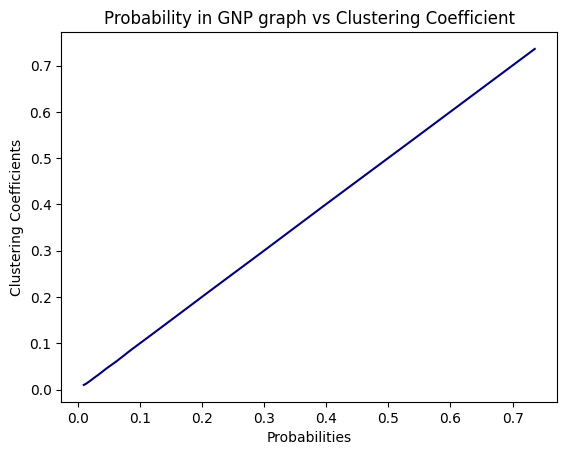

In [2]:
import matplotlib.pyplot as plt
plt.plot(probabilities,Clustering_coeffs, color = 'navy')
plt.xlabel('Probabilities')
plt.ylabel('Clustering Coefficients')

plt.title("Probability in GNP graph vs Clustering Coefficient")
plt.show()